# Breast cancer classification

Wisconsin dataset, 569 cases, 30 measurements each. Malignant is the positive
class, so the number that matters is how many malignant cases we catch.

Three things here are deliberate: compare a neural net against a plain logistic
regression, use cross-validation so the scores are stable instead of luck of one
split, and set the decision threshold for the cost that actually matters, which is
missing a malignant case.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel("ERROR")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series((data.target == 0).astype(int))  # 1 = malignant, 0 = benign
print("shape:", X.shape)
y.value_counts().rename({0: "benign", 1: "malignant"}).to_dict()

shape: (569, 30)


{'benign': 357, 'malignant': 212}

In [3]:
# keep a test set we only look at once, at the end
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print("train:", X_train.shape[0], "test:", X_test.shape[0])

train: 455 test: 114


## Comparing both models with cross-validation

The test set is only ~114 cases, so one split is noisy. I compare the two models
with 5-fold cross-validation on the training data and report average recall and
ROC-AUC with their spread.

In [4]:
def build_net(n_features):
    net = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    net.compile(optimizer="adam", loss="binary_crossentropy")
    return net

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scores = {"logreg": {"recall": [], "auc": []}, "neural net": {"recall": [], "auc": []}}

Xtr, ytr = X_train.to_numpy(), y_train.to_numpy()
for tr, val in skf.split(Xtr, ytr):
    sc = StandardScaler().fit(Xtr[tr])
    xt, xv = sc.transform(Xtr[tr]), sc.transform(Xtr[val])
    yt, yv = ytr[tr], ytr[val]

    lr = LogisticRegression(max_iter=5000).fit(xt, yt)
    lp = lr.predict_proba(xv)[:, 1]
    scores["logreg"]["recall"].append(recall_score(yv, lp >= 0.5))
    scores["logreg"]["auc"].append(roc_auc_score(yv, lp))

    net = build_net(xt.shape[1])
    net.fit(xt, yt, epochs=60, batch_size=16, verbose=0)
    nb = net.predict(xv, verbose=0).ravel()
    scores["neural net"]["recall"].append(recall_score(yv, nb >= 0.5))
    scores["neural net"]["auc"].append(roc_auc_score(yv, nb))

for name, m in scores.items():
    print(f"{name:11s} recall {np.mean(m['recall']):.3f} +/- {np.std(m['recall']):.3f}"
          f"   auc {np.mean(m['auc']):.3f} +/- {np.std(m['auc']):.3f}")

logreg      recall 0.953 +/- 0.040   auc 0.996 +/- 0.005
neural net  recall 0.971 +/- 0.032   auc 0.995 +/- 0.005


The two land within noise of each other. On 569 clean rows a linear model is
already strong, so I take logistic regression forward: simpler, faster, and easy
to explain, which counts for a lot in a medical setting.

## Setting the threshold for the cost that matters

The default 0.5 cutoff misses some malignant cases. I pick the highest threshold
that still catches at least 98% of malignant cases in cross-validation on the
training data (keeping false alarms as low as possible), then apply that fixed
threshold to the untouched test set.

In [5]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

cv_proba = cross_val_predict(model, X_train, y_train, cv=skf, method="predict_proba")[:, 1]
prec, rec, thr = precision_recall_curve(y_train, cv_proba)
target_recall = 0.98
ok = rec[:-1] >= target_recall
chosen = float(thr[ok].max()) if ok.any() else 0.5
print(f"threshold to catch {target_recall:.0%} of malignant in CV: {chosen:.3f}")

threshold to catch 98% of malignant in CV: 0.207


In [6]:
model.fit(X_train, y_train)
test_proba = model.predict_proba(X_test)[:, 1]

for label, t in [("default 0.50", 0.5), (f"recall-first {chosen:.2f}", chosen)]:
    pred = (test_proba >= t).astype(int)
    missed = int(((pred == 0) & (y_test.to_numpy() == 1)).sum())
    print(f"{label}: recall {recall_score(y_test, pred):.3f}, "
          f"precision {precision_score(y_test, pred):.3f}, "
          f"malignant missed {missed}")

default 0.50: recall 0.929, precision 0.975, malignant missed 3
recall-first 0.21: recall 0.976, precision 0.932, malignant missed 1


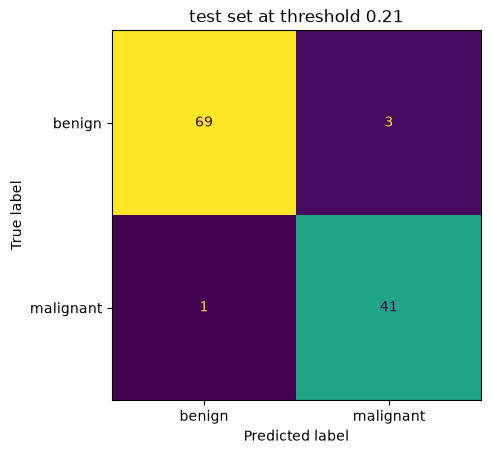

In [7]:
pred = (test_proba >= chosen).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["benign", "malignant"]).plot(colorbar=False)
plt.title(f"test set at threshold {chosen:.2f}")
plt.show()

## What the model leans on

The standardized coefficients show which measurements push a case toward malignant
(right) or benign (left). Bigger bars carry more weight.

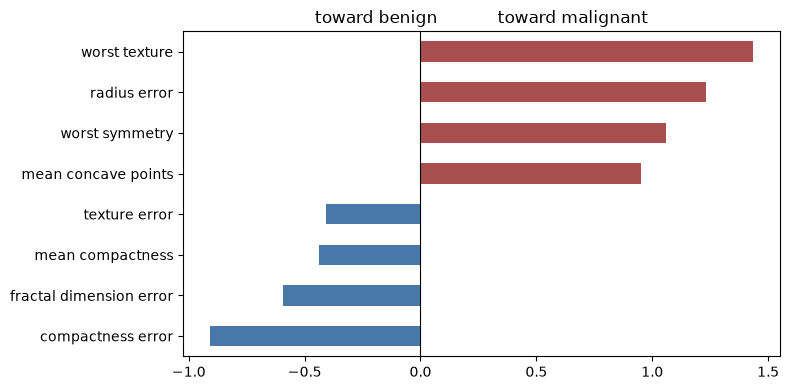

In [8]:
coefs = model.named_steps["logisticregression"].coef_[0]
weights = pd.Series(coefs, index=X.columns).sort_values()
top = pd.concat([weights.head(4), weights.tail(4)])
plt.figure(figsize=(8, 4))
top.plot.barh(color=["#4878a8" if v < 0 else "#a85050" for v in top])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("toward benign            toward malignant")
plt.tight_layout()
plt.show()

## The cases it gets wrong

At the default 0.5 cutoff, most of the misclassified test cases sit close to 0.5,
so they are borderline calls. The occasional confident miss is a genuinely hard
case, and it is what makes catching every last malignant case expensive.

In [9]:
default_pred = (test_proba >= 0.5).astype(int)
wrong = default_pred != y_test.to_numpy()
print(f"misclassified at 0.5: {wrong.sum()} of {len(y_test)}")
print("their probabilities:", np.round(test_proba[wrong], 2))

misclassified at 0.5: 4 of 114
their probabilities: [0.51 0.06 0.31 0.49]


## Takeaway

The neural net and logistic regression score the same, so the simple model wins on
cost and clarity. The value is in the evaluation: cross-validation for stable
numbers, a threshold set to catch malignant cases, and a check that the few errors
are genuinely borderline. On a small, clean dataset, a heavier model adds nothing.